### 0. 환경 설정 — 위젯/진행바 비활성화
`load_dataset`·`.map()`·`from_pretrained` 의 **ipywidget 진행바**가 VS Code 에서
`i is not a function` 렌더 오류를 내는 것을 막는다. **모든 import 보다 먼저** 실행할 것.

In [17]:
# ── widget 렌더러 오류 방지 + 진행바 비활성 (VS Code Jupyter) ──────
# load_dataset/.map()/from_pretrained 의 위젯 진행바가 'i is not a function'
# 렌더 에러를 유발 → 텍스트/비활성으로 강제. 모든 import보다 먼저 실행할 것.
import os
os.environ['HF_HUB_DISABLE_PROGRESS_BARS'] = '1'
os.environ['HF_DATASETS_DISABLE_PROGRESS_BARS'] = '1'   # datasets 는 별도 변수
os.environ['TOKENIZERS_PARALLELISM'] = 'false'
os.environ['TQDM_NOTEBOOK'] = 'false'


# Document AI: Hugging Face Transformers로 Donut 문서 파싱 파인튜닝

이 노트북에서는 **Donut-base**([`naver-clova-ix/donut-base`](https://huggingface.co/naver-clova-ix/donut-base))를
Hugging Face Transformers로 **문서 이해 / 문서 파싱** 태스크에 맞게 파인튜닝하는 방법을 다룬다.
Donut은 OCR 없이도 SOTA 성능을 내는 문서 이해 모델이며, **MIT 라이선스**라 LayoutLMv2/v3와 달리
상업적 이용이 자유롭다.

데이터셋은 **SROIE**([ICDAR-2019-SROIE](https://github.com/zzzDavid/ICDAR-2019-SROIE), 스캔 영수증 1,000장 + OCR)를 사용한다.

### 목차
1. 개발 환경 설정
2. SROIE 데이터셋 로드
3. Donut 학습용 데이터 준비
4. Donut 모델 파인튜닝 & 평가

## 빠른 소개: Donut (ClovaAI)

**Donut**(Document Understanding Transformer)은 **OCR 엔진 없이** 스캔 문서를 이해하는 Transformer 모델이다.
문서 분류·정보 추출(문서 파싱) 등 다양한 시각 문서 이해 태스크에서 SOTA를 달성한다.
구조는 **비전 인코더([Swin Transformer](https://huggingface.co/docs/transformers/model_doc/swin)) +
텍스트 디코더([BART](https://huggingface.co/docs/transformers/model_doc/bart))**의 멀티모달 seq2seq이다.
인코더가 이미지를 임베딩으로 바꾸면, 디코더가 그 임베딩을 받아 토큰 시퀀스를 생성한다.

![donut](assets/donut.png)

- 논문: https://arxiv.org/abs/2111.15664
- 공식 repo: https://github.com/clovaai/donut

---

이제 Donut의 동작 원리를 알았으니 시작해보자. 🚀

_참고: 원본 튜토리얼은 NVIDIA V100(AWS p3.2xlarge)에서 작성·실행되었다._

## 1. 개발 환경 설정

먼저 Hugging Face 라이브러리(`transformers`, `datasets` 등)를 설치한다.
아래 셀을 실행하면 학습에 필요한 패키지가 모두 설치된다.

### 1. 의존성 설치
`transformers`(≥4.22), `datasets`(데이터 로딩), `sentencepiece`(Donut 토크나이저),
`tensorboard`(학습 로그)를 설치한다. 이미 설치돼 있으면 건너뛰어도 된다.

In [18]:
# !pip install -q "transformers>=4.22.0" # comment in when version is released
# !pip install -q datasets sentencepiece tensorboard 

### git-lfs 설치 (선택)
모델/로그를 HuggingFace Hub 로 푸시할 때 필요한 대용량 파일 도구. **이 노트북은
`push_to_hub=False` 로 바꿔 로컬 학습만 하므로 실행하지 않아도 된다.**

In [19]:
# install git-fls for pushing model and logs to the hugging face hub
# !sudo apt-get install git-lfs --yes

원본은 학습 결과물을 **Hugging Face Hub**(원격 모델 버전 관리)에 푸시하려고 `notebook_login`으로
로그인한다. 계정이 있으면 토큰을 디스크에 저장한다.
> 이 노트북은 `push_to_hub=False`로 바꿔 **로컬 학습만** 하므로 이 단계는 건너뛰어도 된다.

### Hub 로그인 (비활성)
원본은 학습 결과를 Hub 로 푸시하려고 로그인했지만, **`push_to_hub=False` 로 바꿔
비활성화**했다. 본인 계정으로 푸시하려면 주석을 풀고 실행한다.

In [20]:
# push_to_hub=False 라 허브 로그인 불필요. 푸시하려면 아래 두 줄 주석 해제 후 실행.
# from huggingface_hub import notebook_login
# notebook_login()

## 2. SROIE 데이터셋 로드

**SROIE**(스캔 영수증 1,000장 + OCR, ICDAR-2019 task 2)를 사용한다. Hugging Face 에 올라온
`darentang/sroie` 는 Donut 과 호환되지 않으므로, **원본 데이터셋**을 받아 `datasets` 의
`imagefolder` 기능으로 로드한다.

### 2. SROIE 데이터셋 내려받기
영수증 데이터셋(ICDAR-2019-SROIE)을 clone 해 `data/img`(이미지) + `data/key`(정답 JSON)로
정리한다. `%%bash` 는 **커널의 현재 작업 디렉터리**(여기선 `SROIE_donut/`)에 받는다.

In [21]:
%%bash 
# clone repository
git clone https://github.com/zzzDavid/ICDAR-2019-SROIE.git
# copy data
cp -r ICDAR-2019-SROIE/data ./
# clean up
rm -rf ICDAR-2019-SROIE
rm -rf data/box

Cloning into 'ICDAR-2019-SROIE'...


이제 `data/` 안에 영수증 **이미지** 폴더와 **OCR 텍스트(정답)** 폴더가 생겼다.
다음 단계는 `imagefolder` 가 읽을 수 있도록 이미지 정보(+OCR 텍스트)를 담은
`metadata.jsonl` 을 만드는 것이다.

최종 형태는 **한 줄에 하나의 JSON**(파일명 + text):
```json
{"file_name": "0001.png", "text": "..."}
{"file_name": "0002.png", "text": "..."}
```
여기서 `"text"` 컬럼이 이미지의 정답(OCR 텍스트)이며, 나중에 Donut 전용 토큰 형식으로 변환된다.

### 정답 JSON → `metadata.jsonl` (imagefolder 포맷)
`data/key/*.json` 정답을 각각 **한 줄 JSON 문자열("text" 컬럼)** 로 만들어
`data/img/metadata.jsonl` 에 저장한다. 이러면 `imagefolder` 로더가 이미지와 정답을
자동으로 짝짓는다. 변환 후 `key/` 폴더는 삭제.

In [22]:
import os
import json
from pathlib import Path
import shutil

# define paths
base_path = Path("data")
metadata_path = base_path.joinpath("key")
image_path = base_path.joinpath("img")
# define metadata list
metadata_list = []

# parse metadata
for file_name in metadata_path.glob("*.json"):
  with open(file_name, "r") as json_file:
    # load json file
    data = json.load(json_file)
    # create "text" column with json string
    text = json.dumps(data)
    # add to metadata list if image exists
    if image_path.joinpath(f"{file_name.stem}.jpg").is_file():    
      metadata_list.append({"text":text,"file_name":f"{file_name.stem}.jpg"})
      # delete json file
      
# write jsonline file
with open(image_path.joinpath('metadata.jsonl'), 'w') as outfile:
    for entry in metadata_list:
        json.dump(entry, outfile)
        outfile.write('\n')

# remove old meta data
shutil.rmtree(metadata_path)

좋다! 이제 `datasets` 의 `imagefolder` 기능으로 데이터셋을 로드할 수 있다.

### 경로 변수 준비
이후 셀에서 쓸 `data/img`·`data/key` 경로를 정의하는 준비용 셀.

In [23]:
import os
import json
from pathlib import Path
import shutil

# define paths
base_path = Path("data")
metadata_path = base_path.joinpath("key")
image_path = base_path.joinpath("img")
# define metadata list

### `imagefolder` 로 데이터셋 로드
`data/img/`(이미지 + metadata.jsonl)를 HuggingFace Dataset 으로 로드한다.
`image`(영수증) + `text`(정답 JSON 문자열) 컬럼이 생긴다.

In [24]:
from datasets import load_dataset

# Load dataset
dataset = load_dataset("imagefolder", data_dir=image_path, split="train")

print(f"Dataset has {len(dataset)} images")
print(f"Dataset features are: {dataset.features.keys()}")

Dataset has 626 images
Dataset features are: dict_keys(['text', 'image'])


이제 데이터셋을 좀 더 자세히 살펴보자.

### 데이터 살펴보기
임의 샘플 하나의 정답 텍스트와 이미지를 출력해 데이터가 제대로 로드됐는지 눈으로 확인한다.

Random sample is 79
OCR text is {"company": "MR. D.I.Y. (M) SDN BHD", "date": "18-03-18", "address": "LOT 1851-A & 1851-B, JALAN KPB 6, KAWASAN PERINDUSTRIAN BALAKONG, 43300 SERI KEMBANGAN, SELANGOR", "total": "10.60"}


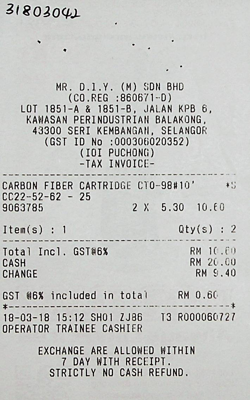

In [25]:
import random

random_sample = random.randint(0, len(dataset))

print(f"Random sample is {random_sample}")
print(f"OCR text is {dataset[random_sample]['text']}")
dataset[random_sample]['image'].resize((250,400))


## 3. Donut 학습용 데이터 준비

Donut 은 비전 인코더 + 텍스트 디코더의 seq2seq 모델이다. 파인튜닝 시 이미지로부터 `"text"` 를
생성하도록 학습시킨다. 그러려면 NLP 처럼 텍스트를 토크나이즈·전처리해야 하는데, 그 전에
**JSON 문자열을 Donut 호환 토큰 문서로 변환**해야 한다.

**원본 JSON 문자열**
```json
{"company": "ADVANCO COMPANY", "date": "17/01/2018", "address": "...", "total": "7.00"}
```
**Donut 토큰 문서**
```
<s></s><s_company>ADVANCO COMPANY</s_company><s_date>17/01/2018</s_date><s_address>...</s_address><s_total>7.00</s_total></s>
```
ClovaAI 의 [`json2token`](https://github.com/clovaai/donut/blob/master/donut/model.py) 메서드를 가져와 이 변환을 수행한다.

### 3. Donut 학습용 전처리 — JSON → 토큰 시퀀스
Donut 은 정답 JSON 을 **XML 스타일 토큰**으로 표현한다
(`{"total":"x"}` → `<s_total>x</s_total>`). `json2token` 이 이 변환을 하면서
**등장하는 모든 필드 키를 `new_special_tokens` 로 수집**한다.

**중요 포인트**
- 키는 `sorted(..., reverse=True)` 로 **역정렬** → 항상 같은 순서(결정적).
- 여기서 모은 필드 토큰을 다음 단계에서 토크나이저에 등록해야 디코더가 생성할 수 있다.

In [26]:
new_special_tokens = [] # new tokens which will be added to the tokenizer
task_start_token = "<s>"  # start of task token
eos_token = "</s>" # eos token of tokenizer

def json2token(obj, update_special_tokens_for_json_key: bool = True, sort_json_key: bool = True):
    """
    Convert an ordered JSON object into a token sequence
    """
    if type(obj) == dict:
        if len(obj) == 1 and "text_sequence" in obj:
            return obj["text_sequence"]
        else:
            output = ""
            if sort_json_key:
                keys = sorted(obj.keys(), reverse=True)
            else:
                keys = obj.keys()
            for k in keys:
                if update_special_tokens_for_json_key:
                    new_special_tokens.append(fr"<s_{k}>") if fr"<s_{k}>" not in new_special_tokens else None
                    new_special_tokens.append(fr"</s_{k}>") if fr"</s_{k}>" not in new_special_tokens else None
                output += (
                    fr"<s_{k}>"
                    + json2token(obj[k], update_special_tokens_for_json_key, sort_json_key)
                    + fr"</s_{k}>"
                )
            return output
    elif type(obj) == list:
        return r"<sep/>".join(
            [json2token(item, update_special_tokens_for_json_key, sort_json_key) for item in obj]
        )
    else:
        # excluded special tokens for now
        obj = str(obj)
        if f"<{obj}/>" in new_special_tokens:
            obj = f"<{obj}/>"  # for categorical special tokens
        return obj


def preprocess_documents_for_donut(sample):
    # create Donut-style input
    text = json.loads(sample["text"])
    d_doc = task_start_token + json2token(text) + eos_token
    # convert all images to RGB
    image = sample["image"].convert('RGB')
    return {"image": image, "text": d_doc}

# dataset의 각 샘플을 Donut 학습용 입력(이미지 RGB 변환 + JSON → 토큰 시퀀스) 형태로 변환한다.
proc_dataset = dataset.map(preprocess_documents_for_donut)

print(f"Sample: {proc_dataset[45]['text']}")
print(f"New special tokens: {new_special_tokens + [task_start_token] + [eos_token]}")


Sample: <s><s_total>RM 22.90</s_total><s_date>17-04-16</s_date><s_company>MR. D.I.Y. (KUCHAI) SDN BHD</s_company><s_address>LOT 1851-A & 1851-B, JALAN KPB 6, KAWASAN PERINDUSTRIAN BALAKONG, 43300 SERI KEMBANGAN, SELANGOR</s_address></s>
New special tokens: ['<s_total>', '</s_total>', '<s_date>', '</s_date>', '<s_company>', '</s_company>', '<s_address>', '</s_address>', '<s>', '</s>']


다음은 텍스트를 토크나이즈하고 이미지를 텐서로 인코딩하는 단계다. `DonutProcessor` 를 불러와
새 특수 토큰을 추가하고, 처리 시 이미지 크기를 사전학습 `[2560, 1920]` 보다 작은
**`[1280, 960]`** 으로 맞춘다(성능 개선: 영수증 작은 글자 보존 ↔ VRAM/속도 절충).

### 프로세서 로드 + 필드 토큰 등록 + 해상도 설정
`DonutProcessor` 를 불러와 위에서 수집한 **필드 토큰 + task/eos 토큰을 등록**한다.

#### 왜 토큰을 "등록"해야 하나? (직관)
> 토크나이저는 **자기가 아는 토큰만** 읽고 쓸 수 있다. `<s_total>` 같은 필드 토큰은 원래 사전에 없어서,
> 등록하지 않으면 모델이 그걸 **읽지도 쓰지도 못한다.** (키보드에 없는 키는 칠 수 없는 것과 같다.)

**등록 안 하면** — 정답 `<s_total>7.00</s_total>` 이 의미 없는 조각으로 부서져 필드 구조가 사라진다:
`"<","s","_","total",">", ...` ← "total 필드 시작"이라는 신호 소실.
**등록하면** — `<s_total>` 이 **토큰 1개**로 잡혀 필드 경계가 한 덩어리로 보존된다.

| 방향 | 등록이 필요한 이유 |
|---|---|
| **학습(정답 인코딩)** | 정답을 깔끔한 토큰으로 만들어야 모델이 JSON **필드 구조**를 배울 수 있음 |
| **추론(토큰 생성)** | 출력층은 **사전에 있는 토큰만** 뱉음 → 등록 안 하면 `<s_total>` 출력 슬롯 자체가 없어 **생성 불가** |

그래서 등록 직후 `resize_token_embeddings` 로 새 토큰마다 **임베딩 행 + 출력 슬롯**을 추가한다.

- **`<s>` (task/시작 토큰)** = "문서 파싱 **시작**" 출발 신호(`decoder_start_token_id`).
- **`</s>` (eos/끝 토큰)** = "여기서 **끝**" 신호 — 없으면 모델이 언제 멈출지 몰라 계속 생성한다.
> 받아쓰기의 **"시작!"·"끝!"** 구령과 같다.

**중요 포인트**
- `image_processor.size` 는 **dict** `{"height":1280,"width":960}` 형식(신버전). 사전학습 `[2560,1920]` 보다 작게 잡아 VRAM/속도를 아끼되, 영수증 작은 글자가 뭉개지지 않도록 1280×960 으로 설정(성능 개선). cell-42 의 `encoder.image_size` 가 이 값을 따라가며 Swin 위치 임베딩이 자동 보간된다.
- `do_align_long_axis=False` — 세로 이미지를 회전 없이 원본 방향대로 사용.

In [ ]:
from transformers import DonutProcessor

# Load processor
processor = DonutProcessor.from_pretrained("naver-clova-ix/donut-base", use_fast=False)

# add new special tokens to tokenizer
processor.tokenizer.add_special_tokens({"additional_special_tokens": new_special_tokens + [task_start_token] + [eos_token]})

# we update some settings which differ from pretraining; namely the size of the images + no rotation required
# 성능 개선: 해상도 상향 960x720 → 1280x960.
# 영수증은 세로로 길고 글자가 빽빽해 주소/합계 같은 작은 글자가 저해상도에서 뭉갠다.
# RTX 5090(32GB)이면 감당 가능하나 VRAM/속도 부담이 커지므로 cell-45 에서 배치를 4 로 낮춘다.
# 신버전 image_processor.size 는 dict {"height":..,"width":..} 기대 (리스트 X)
processor.image_processor.size = {"height": 1280, "width": 960}
processor.image_processor.do_align_long_axis = False

이제 학습에 사용할 데이터셋을 준비한다.

### 이미지+정답 → 학습 텐서로 변환 (`.map`)
각 샘플을 `pixel_values`(이미지 텐서) + `labels`(정답 토큰 ID)로 변환한다.

**중요 포인트**
- `random_padding`(train) — 이미지 패딩 위치를 무작위화해 일종의 증강 효과.
  ⚠️ **transformers 5.12+ 에서는 image processor 가 `random_padding` 인자를 더 이상 받지 않는다**
  (strict-kwargs). `_make_pixel_values` 가 버전을 자동 감지해 신버전이면 중앙 패딩으로 폴백한다
  (증강은 빠지지만 학습은 정상). 구버전(5.3 등)에서는 증강이 그대로 동작.
- 정답은 `max_length=512` 로 패딩/잘림, **패딩 위치는 `-100`** 으로 마스킹해 loss 에서 제외.
- ⚠️ `.map` 전체 변환은 RAM 을 많이 쓴다(원 주석: 32~64GB 권장).
- ⚠️ **예전엔 `try/except: return {}` 로 모든 예외를 삼켜**, `random_padding` API 차이로 전 샘플이
  실패하면 `processed_dataset` 가 조용히 **0행**(`features=[], num_rows=0`)이 됐다. 이 함정을 제거했다.

In [28]:
def _make_pixel_values(image, processor, train):
    # transformers 버전별 random_padding 지원 차이 흡수.
    # - 구버전(예: 5.3): preprocess 가 random_padding 인자를 받아 학습 증강 가능
    #   (패딩 영역 안에서 이미지를 무작위 위치에 배치).
    # - 신버전(5.12+): DonutImageProcessor 가 strict-kwargs 로 바뀌어 random_padding 을
    #   더 이상 받지 않음 → TypeError. 내부적으로 중앙 패딩으로 고정되므로 인자 없이 호출.
    ip = processor.image_processor
    try:
        return ip(image, random_padding=train, return_tensors="pt").pixel_values.squeeze()
    except TypeError:
        # 신버전 폴백: random_padding 미지원 → 중앙 패딩(증강 없음)
        return ip(image, return_tensors="pt").pixel_values.squeeze()


def transform_and_tokenize(sample, processor=processor, split="train", max_length=512, ignore_id=-100):
    # create tensor from image
    # ⚠️ 예전 코드의 `try/except Exception: return {}` 는 제거했다.
    #    모든 샘플이 같은 API 차이(random_padding)로 실패하면 빈 dict 가 반환돼
    #    processed_dataset 가 조용히 0행이 되는 함정이었다(features=[], num_rows=0).
    #    이제 버전 차이는 _make_pixel_values 가 흡수하고, 진짜 문제는 즉시 에러를 낸다.
    pixel_values = _make_pixel_values(sample["image"], processor, split == "train")

    # tokenize document
    input_ids = processor.tokenizer(
        sample["text"],
        add_special_tokens=False,
        max_length=max_length,
        padding="max_length",
        truncation=True,
        return_tensors="pt",
    )["input_ids"].squeeze(0)

    labels = input_ids.clone()
    labels[labels == processor.tokenizer.pad_token_id] = ignore_id  # model doesn't need to predict pad token
    return {"pixel_values": pixel_values, "labels": labels, "target_sequence": sample["text"]}

# need at least 32-64GB of RAM to run this
processed_dataset = proc_dataset.map(transform_and_tokenize, remove_columns=["image", "text"])

In [29]:
processed_dataset

Dataset({
    features: ['pixel_values', 'labels', 'target_sequence'],
    num_rows: 626
})

### (선택) 전처리 결과 디스크 저장/복원
오래 걸리는 `.map` 결과를 디스크에 저장해 두면 나중에 에러가 나도 다시 안 돌려도 된다.
필요할 때 주석을 풀어 사용(기본은 비활성).

In [30]:
# from datasets import load_from_disk
# from transformers import DonutProcessor

## COMMENT IN in case you want to save the processed dataset to disk in case of error later
# processed_dataset.save_to_disk("processed_dataset")
# processor.save_pretrained("processor")

## COMMENT IN in case you want to load the processed dataset from disk in case of error later
# processed_dataset = load_from_disk("processed_dataset")
# processor = DonutProcessor.from_pretrained("processor")


마지막으로 데이터셋을 train / validation 으로 나눈다.

### 학습/검증 분할
전처리된 데이터를 train/test 로 나눈다(`test_size=0.1`).

In [31]:
from datasets import Dataset

# train_test_split 은 Dataset 에만 있음. 셀을 재실행하면 processed_dataset 이
# 이미 DatasetDict{train,test} 라 AttributeError 가 난다 → 타입을 보고 안전하게 처리.
if isinstance(processed_dataset, Dataset):
    processed_dataset = processed_dataset.train_test_split(test_size=0.1)
elif "test" not in processed_dataset:
    # DatasetDict 인데 test 가 없으면(예: load_dataset 이 train 만 준 경우) train 을 분할
    processed_dataset = processed_dataset["train"].train_test_split(test_size=0.1)
else:
    print("이미 train/test 로 분할되어 있습니다 — 분할 건너뜀")

print(processed_dataset)

DatasetDict({
    train: Dataset({
        features: ['pixel_values', 'labels', 'target_sequence'],
        num_rows: 563
    })
    test: Dataset({
        features: ['pixel_values', 'labels', 'target_sequence'],
        num_rows: 63
    })
})


## 4. Donut 모델 파인튜닝 & 평가

데이터 전처리가 끝났으니 학습을 시작한다. 먼저 `VisionEncoderDecoderModel` 로
`naver-clova-ix/donut-base` 를 로드한다. `donut-base` 는 **사전학습 가중치만** 포함하며,
논문 [OCR-free Document Understanding Transformer](https://arxiv.org/abs/2111.15664)(Geewook et al.)에서 소개되었다.

### 4. 모델 로드 & 설정
사전학습 Donut 을 불러와 새 토큰 수에 맞게 임베딩을 늘리고, 해상도·시작 토큰을 맞춘다.

**중요 포인트**
- `model.loss_type = "ForCausalLM"` — `loss_type=None` 경고 제거(동작 동일).
- `resize_token_embeddings(..., mean_resizing=False)` — 새 토큰을 **랜덤 초기화**(원본 레시피와 동일, 결정적).
- `decoder.max_length` 를 학습셋 라벨 최대 길이에 맞춰 설정.

In [34]:
import torch
from transformers import VisionEncoderDecoderModel, VisionEncoderDecoderConfig

# Load model from huggingface.co
model = VisionEncoderDecoderModel.from_pretrained("naver-clova-ix/donut-base")
# VED는 클래스명이 LOSS_MAPPING과 안 맞아 loss_type=None 경고 → 동일 fallback 명시
model.loss_type = "ForCausalLM"

# Resize embedding layer to match vocabulary size
new_emb = model.decoder.resize_token_embeddings(len(processor.tokenizer), mean_resizing=False)
print(f"New embedding size: {new_emb}")
# Adjust our image size and output sequence lengths
model.config.encoder.image_size = [processor.image_processor.size["height"], processor.image_processor.size["width"]] # (height, width)
model.config.decoder.max_length = len(max(processed_dataset["train"]["labels"], key=len))

# Add task token for decoder to start
model.config.pad_token_id = processor.tokenizer.pad_token_id
model.config.decoder_start_token_id = processor.tokenizer.convert_tokens_to_ids(['<s>'])[0]

# is done by Trainer
# device = "cuda" if torch.cuda.is_available() else "cpu"
# model.to(device)

New embedding size: MBartScaledWordEmbedding(57533, 1024, padding_idx=1)


학습 전에 `Seq2SeqTrainingArguments` 로 하이퍼파라미터를 정의한다.
> 원본은 학습 중 체크포인트·로그·metric 을 Hub 레포로 자동 푸시하지만, 이 노트북은
> `push_to_hub=False` 로 **로컬 저장만** 한다.

### 학습 하이퍼파라미터 + Trainer 구성
`Seq2SeqTrainingArguments` 로 학습 설정을 정의하고 `Seq2SeqTrainer` 를 만든다.

**중요 포인트(성능 개선 반영)**
- **`fp16=False` + `bf16=use_bf16`** — Donut 은 fp16 에서 수치 불안정 → bf16 권장. `use_bf16` 은 GPU 지원 여부 자동 감지(Ampere+), 미지원이면 fp32.
- **학습 강화** — `num_train_epochs=20`(3→20, 과소학습 방지) + `warmup_ratio=0.1` + `lr_scheduler_type="cosine"` + `learning_rate=3e-5`.
- **best 모델 자동 선택** — `load_best_model_at_end=True`(가장 낮은 `eval_loss` 체크포인트 복원). 이를 위해 `save_strategy`·`eval_strategy` 를 **둘 다 `steps`(100)** 로 맞췄다.
- **`push_to_hub=False`** — 로컬에서만 학습/저장(`hub_*` 인자는 주석 처리).
- `predict_with_generate=False` — eval 시 generate 생략하고 손실만 빠르게 계산.

In [ ]:
# huggingface_hub 1.x 에서 HfFolder 가 제거됨 → import 불필요(아래 hub_token 도 주석 처리).
# 토큰이 필요하면: from huggingface_hub import get_token; get_token()
from transformers import Seq2SeqTrainingArguments, Seq2SeqTrainer

# hyperparameters used for multiple args
hf_repository_id = "donut-base-sroie"

# Arguments for training
# bf16은 Ampere+ 에서만 지원 → 자동 감지. 미지원이면 fp32 (fp16은 Donut 수치 불안정이라 미사용)
import torch
use_bf16 = torch.cuda.is_available() and torch.cuda.is_bf16_supported()
print(f'bf16 사용: {use_bf16}')
training_args = Seq2SeqTrainingArguments(
    output_dir=hf_repository_id,
    # ── 성능 개선: 학습 강화 ──────────────────────────────────────
    # SROIE(563장)에 3 epoch 은 과소학습. 15~30 사이에서 eval_loss 보며 조절.
    num_train_epochs=20,
    learning_rate=3e-5,
    # 워밍업: Donut 은 초반 워밍업이 중요(원래는 없었음).
    # transformers 5.12 에서 warmup_ratio 가 deprecated 라 warmup_steps 로 지정.
    # 유효 배치 8 기준 총 스텝 ≈ ceil(563/8) * 20 ≈ 1420 → 약 10% = 140.
    warmup_steps=140,
    lr_scheduler_type="cosine",       # 워밍업 후 코사인 감쇠
    # 해상도 1280x960(cell-30) 에서는 VRAM 부담이 커 batch_size 를 4 로 낮추고
    # gradient_accumulation_steps=2 로 유효 배치를 8 로 유지한다(스텝 수·warmup 그대로).
    # VRAM 여유가 있으면(OOM 안 나면) batch_size=8, grad_accum=1 로 되돌려도 된다.
    per_device_train_batch_size=4,
    per_device_eval_batch_size=4,
    gradient_accumulation_steps=2,
    weight_decay=0.01,
    fp16=False,
    bf16=use_bf16,
    logging_steps=100,
    save_total_limit=2,
    # ── best 체크포인트 자동 선택 ────────────────────────────────
    # load_best_model_at_end=True 는 save_strategy 와 eval_strategy 가 같아야 동작한다.
    # (예전엔 save=epoch / eval=steps 로 불일치였음 → 둘 다 steps 로 통일)
    eval_strategy="steps",
    eval_steps=100,
    save_strategy="steps",
    save_steps=100,
    load_best_model_at_end=True,
    metric_for_best_model="eval_loss",
    greater_is_better=False,          # eval_loss 는 낮을수록 좋음
    predict_with_generate=False,      # 손실만 빠르게 계산 (eval 시 generate 생략)
    # push to hub parameters
    report_to="none",   # tensorboard 미설치 → 비활성. (설치 시 "tensorboard"로 되돌리면 로그 기록)
    push_to_hub=False,
    # push_to_hub=False 라 아래 hub_* 는 불필요 (로그인 의존 제거)
    # hub_strategy="every_save",
    # hub_model_id=hf_repository_id,
    # hub_token=get_token(),
)

# Create Trainer
trainer = Seq2SeqTrainer(
    model=model,
    args=training_args,
    train_dataset=processed_dataset["train"],
    eval_dataset=processed_dataset["test"],   # Validation Loss 계산용
)

이제 `Seq2SeqTrainer` 의 `train()` 메서드로 학습을 시작한다.

### 학습 실행
`trainer.train()` 으로 학습을 시작한다. 매 epoch 마다 체크포인트가 `output_dir` 에 저장된다.

In [41]:
# Start training
trainer.train()

Step,Training Loss,Validation Loss
50,0.325913,0.243307
100,0.240865,0.240221
150,0.209774,0.220207
200,0.139440,0.224775
250,0.106248,0.224665
300,0.097283,0.232357
350,0.076663,0.230606
400,0.058686,0.246175
450,0.049515,0.248196
500,0.042387,0.242198


TrainOutput(global_step=710, training_loss=0.1035676788696101, metrics={'train_runtime': 2509.4403, 'train_samples_per_second': 2.244, 'train_steps_per_second': 0.283, 'total_flos': 9.902538334826496e+18, 'train_loss': 0.1035676788696101, 'epoch': 10.0})

학습이 끝나면 프로세서도 함께 저장한다(원본은 Hub 저장 + 모델 카드 생성).
> 로컬 전용으로 바꾼 지금은 Hub 푸시 대신 로컬 경로에 저장하면 된다.

### 프로세서 저장 (+ Hub 푸시는 비활성)
프로세서를 모델과 같은 경로에 저장한다(추론 시 둘 다 같은 경로에서 로드해야 함).
> ⚠️ `trainer.push_to_hub()` / `create_model_card()` 는 Hub 푸시용이라, **로컬 전용으로
> 바꾼 지금은 로그인이 없으면 실패**한다. 로컬 저장만 원하면 그 두 줄은 건너뛰고
> `trainer.save_model(...)` 로 대체하면 된다.

In [42]:
# Save processor and create model card
processor.save_pretrained(hf_repository_id)
# trainer.create_model_card()
# trainer.push_to_hub()

['donut-base-sroie/processor_config.json']

모델 학습에 성공했다. 이제 추론으로 테스트하고 정확도를 평가해보자.

### 5. 추론 테스트
학습된 모델로 영수증 한 장을 파싱해 **예측 vs 정답**을 비교한다.

**중요 포인트**
- `generate()` 가 `<s>` 토큰부터 시작해 EOS 까지 토큰을 자동 생성 → `token2json` 으로 dict 복원.
- ⚠️ 원본은 `philschmid/donut-base-sroie`(원저자 공개 모델)를 불러온다. **본인이 학습한 모델로 평가하려면** 이 경로를 학습 `output_dir`(예: `"donut-base-sroie"`)로 바꿀 것.

In [ ]:
import re
import transformers
from PIL import Image
from transformers import DonutProcessor, VisionEncoderDecoderModel
import torch
import random
import numpy as np

# hidde logs
transformers.logging.disable_default_handler()


# Load our model from Hugging Face
# ⚠️ 본인이 학습한 모델로 평가하려면 아래를 학습 output_dir(예: "donut-base-sroie")로 바꾼다.
#    그대로 두면 원저자 공개 모델을 평가하므로, 위에서 학습한 모델과는 무관하다.
MODEL_PATH = "philschmid/donut-base-sroie"   # or "donut-base-sroie"
processor = DonutProcessor.from_pretrained(MODEL_PATH)
model = VisionEncoderDecoderModel.from_pretrained(MODEL_PATH)

# Move model to GPU
device = "cuda" if torch.cuda.is_available() else "cpu"
model.to(device)

# Load random document image from the test set
test_sample = processed_dataset["test"][random.randint(0, len(processed_dataset["test"]) - 1)]

def run_prediction(sample, model=model, processor=processor):
    # ── 버그 수정: 전역 test_sample 이 아니라 인자 sample 을 사용해야
    #    평가 루프(아래 셀)에서 샘플마다 다른 예측이 나온다. ──
    # prepare inputs
    pixel_values = torch.tensor(sample["pixel_values"]).unsqueeze(0)
    task_prompt = "<s>"
    decoder_input_ids = processor.tokenizer(task_prompt, add_special_tokens=False, return_tensors="pt").input_ids

    # run inference
    outputs = model.generate(
        pixel_values.to(device),
        decoder_input_ids=decoder_input_ids.to(device),
        max_length=model.decoder.config.max_position_embeddings,
        early_stopping=True,
        pad_token_id=processor.tokenizer.pad_token_id,
        eos_token_id=processor.tokenizer.eos_token_id,
        use_cache=True,
        num_beams=4,   # 성능 개선: greedy(1) → 빔서치(4). 약간 느려지지만 필드 추출 정확도 ↑
        bad_words_ids=[[processor.tokenizer.unk_token_id]],
        return_dict_in_generate=True,
    )

    # process output
    prediction = processor.batch_decode(outputs.sequences)[0]
    prediction = processor.token2json(prediction)

    # load reference target
    target = processor.token2json(sample["target_sequence"])
    return prediction, target

prediction, target = run_prediction(test_sample)
# ── 입력 이미지 + 추론 결과를 나란히 출력 ───────────────────────────
import matplotlib.pyplot as plt
import json as _json

# pixel_values 역정규화(mean=std=0.5 → [-1,1] → [0,255])해 PIL 이미지로 복원
_pv  = np.array(test_sample["pixel_values"]).transpose(1, 2, 0)   # (C,H,W) → (H,W,C)
_img = (((_pv + 1) / 2) * 255).clip(0, 255).astype(np.uint8)      # [-1,1] → [0,255]

fig, (ax_img, ax_txt) = plt.subplots(1, 2, figsize=(13, 8),
                                     gridspec_kw={"width_ratios": [1, 1.1]})

# 왼쪽: 입력 영수증 이미지
ax_img.imshow(_img)
ax_img.axis("off")
ax_img.set_title("Input Image", fontsize=13, fontweight="bold")

# 오른쪽: 예측(Prediction) + 정답(Reference)을 JSON 텍스트로
ax_txt.axis("off")
_pred = _json.dumps(prediction, ensure_ascii=False, indent=2)
_gt   = _json.dumps(target,     ensure_ascii=False, indent=2)
ax_txt.text(0.0, 1.00, "Prediction (model)", transform=ax_txt.transAxes,
            fontsize=12, fontweight="bold", color="tab:blue", va="top")
ax_txt.text(0.0, 0.94, _pred, transform=ax_txt.transAxes,
            fontsize=10, family="monospace", va="top", wrap=True)
ax_txt.text(0.0, 0.46, "Reference (ground truth)", transform=ax_txt.transAxes,
            fontsize=12, fontweight="bold", color="tab:green", va="top")
ax_txt.text(0.0, 0.40, _gt, transform=ax_txt.transAxes,
            fontsize=10, family="monospace", va="top", wrap=True)

plt.tight_layout()
plt.show()

# 텍스트로도 한 번 더 출력
print(f"Prediction: {prediction}")
print(f"Target : {target}")


멋지다 😍🔥 파인튜닝된 모델이 문서를 올바르게 파싱해 값을 정확히 추출했다.
다음은 테스트셋 평가다. seq2seq 모델이라 평가가 간단하진 않다.

여기선 단순하게 **정확도(accuracy)** 를 쓴다 — 딕셔너리의 각 키에 대해 예측값과 정답이
**완전히 일치**하는지 비교한다. 이 방식은 완전 일치만 정답으로 치므로 **편향/단순**하다
(예: 공백 하나만 달라도 오답 처리).

### 전체 테스트셋 정확도 평가
테스트셋 전체를 순회하며 필드 값 일치율(정확도)을 계산한다.
> ✅ 수정됨: 원본은 루프 안에서 `run_prediction(test_sample)` 로 **고정된 1장**만 반복 예측하고,
> `run_prediction` 자체도 인자를 무시한 채 전역 `test_sample` 을 쓰는 이중 버그가 있었다.
> 이제 `run_prediction(sample)` 이 루프 변수 `sample` 을 받아 **샘플마다** 예측하므로
> 정확도가 테스트셋 전체를 반영한다.

In [ ]:
import re
from tqdm import tqdm

def _norm(x):
    # 측정 보정: 공백 1칸으로 통일 + 양끝 공백 제거 + 소문자화.
    # 완전 일치(strict)는 공백/대소문자 하나만 달라도 오답 처리해 점수를 과소평가한다.
    return re.sub(r"\s+", " ", str(x)).strip().lower()

# define counter for samples
true_counter = 0
total_counter = 0

# iterate over dataset
for sample in tqdm(processed_dataset["test"]):
  # ── 버그 수정: 고정된 test_sample 이 아니라 루프 변수 sample 로 예측해야
  #    테스트셋 전체에 대한 정확도가 나온다(이전엔 같은 1장만 63번 예측). ──
  prediction, target = run_prediction(sample)
  # token2json 이 dict 가 아닌 경우(파싱 실패 등) 안전 처리
  if not isinstance(prediction, dict):
      prediction = {}
  if not isinstance(target, dict):
      continue
  # ── 정답 키 기준으로 비교 ──
  #   - zip(values) 방식은 짧은 쪽에 맞춰 잘려 누락 필드를 무시했다.
  #   - 정답의 각 키마다 예측값을 꺼내 비교(없으면 ""), 누락도 오답으로 카운트해 공정하게.
  for k, v in target.items():
      if _norm(prediction.get(k, "")) == _norm(v):
          true_counter += 1
      total_counter += 1

print(f"Accuracy (normalized): {(true_counter/total_counter)*100:.2f}%")

모델은 테스트셋에서 **약 75% 정확도**를 달성한다.

_참고: 이 평가는 각 키의 **완전 문자열 일치**만 정답으로 보는 매우 단순한 방식이라 편향이 크다.
즉 75% 는 사실 꽤 좋은 수치다._

예를 들어 모델이 `address` 를 `... X ,U13/X ...` 로 예측하고 정답이 `... X,U13/X ...` 였는데,
`X` 와 `,U13/X` 사이의 **공백 하나** 차이만으로 오답 처리되었다. 평가 루프에선 이런 경우가
정답으로 카운트되지 않는다.